<a href="https://colab.research.google.com/github/dhanushkaputty/DL/blob/main/dataset.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
from tensorflow.keras.datasets import cifar10
import tensorflow as tf
from tensorflow.keras import layers, models


(X_train, y_train), (X_test, y_test) = cifar10.load_data()


X_train = X_train / 255.0
X_test = X_test / 255.0


model = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu'),
    layers.MaxPooling2D(),

    layers.Flatten(),

    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')   # 10 classes
])


model.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)


history = model.fit(
    X_train, y_train,
    epochs=10,
    validation_data=(X_test, y_test)
)

# Evaluate
loss, acc = model.evaluate(X_test, y_test)
print("Test Accuracy:", acc)

Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.3775 - loss: 1.6789 - val_accuracy: 0.4999 - val_loss: 1.3728
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.5284 - loss: 1.3197 - val_accuracy: 0.5940 - val_loss: 1.1392
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.5894 - loss: 1.1678 - val_accuracy: 0.6239 - val_loss: 1.0581
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.6337 - loss: 1.0458 - val_accuracy: 0.6533 - val_loss: 0.9842
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6626 - loss: 0.9639 - val_accuracy: 0.6693 - val_loss: 0.9411
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6869 - loss: 0.9011 - val_accuracy: 0.6910 - val_loss: 0.8860
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7056 - loss: 0.8574 - val_accuracy: 0.7048 - val_loss: 0.8442
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7201 - loss: 0.8104 -

In [6]:
print(history)

In [7]:

y_pred = model.predict(X_test)


y_pred_classes = y_pred.argmax(axis=1)


y_test_classes = y_test.flatten()

313/313 ━━━━━━━━━━━━━━━━━━━━ 1s 3ms/step


In [8]:
from sklearn.metrics import accuracy_score, confusion_matrix, classification_report

# Accuracy
accuracy = accuracy_score(y_test_classes, y_pred_classes)
print("Accuracy (sklearn):", accuracy)

Accuracy (sklearn): 0.7185


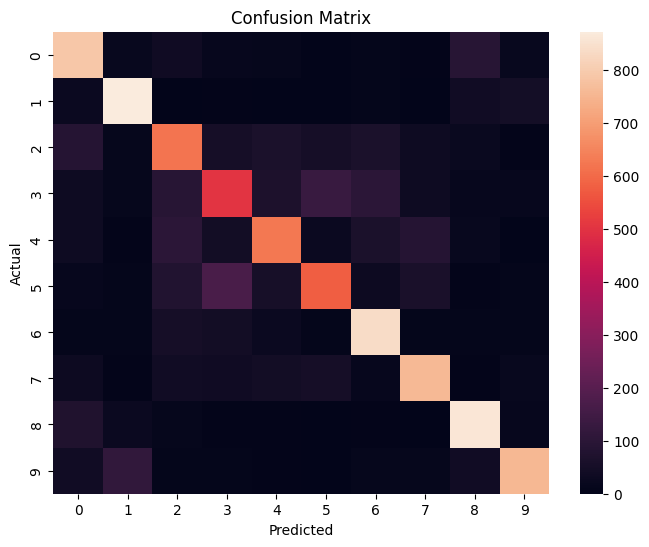

In [4]:
import seaborn as sns
import matplotlib.pyplot as plt

cm = confusion_matrix(y_test_classes, y_pred_classes)

plt.figure(figsize=(8,6))
sns.heatmap(cm, annot=False)
plt.title("Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")
plt.show()

In [5]:
print(classification_report(y_test_classes, y_pred_classes))

              precision    recall  f1-score   support

           0       0.70      0.79      0.74      1000
           1       0.81      0.87      0.84      1000
           2       0.60      0.62      0.61      1000
           3       0.58      0.50      0.54      1000
           4       0.69      0.63      0.66      1000
           5       0.68      0.58      0.63      1000
           6       0.73      0.84      0.78      1000
           7       0.76      0.76      0.76      1000
           8       0.78      0.86      0.82      1000
           9       0.84      0.76      0.80      1000

    accuracy                           0.72     10000
   macro avg       0.72      0.72      0.72     10000
weighted avg       0.72      0.72      0.72     10000



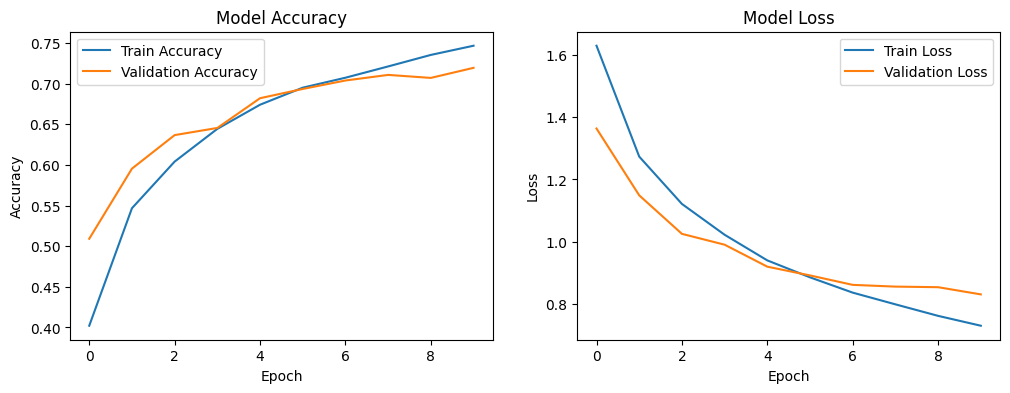

In [6]:
plt.figure(figsize=(12,4))

# Accuracy Graph
plt.subplot(1,2,1)
plt.plot(history.history['accuracy'], label='Train Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Model Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()

# Loss Graph
plt.subplot(1,2,2)
plt.plot(history.history['loss'], label='Train Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Model Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()

plt.show()

In this model, performance is improved by applying data augmentation techniques such as rotation and horizontal flipping to increase dataset diversity. Batch Normalization is added to stabilize and speed up training, and Dropout is used to reduce overfitting. These improvements help in achieving better generalization and higher accuracy.”“An improved CNN model is implemented using data augmentation, batch normalization, and dropout. These techniques enhance model performance by reducing overfitting and improving learning efficiency.”

In [9]:
from tensorflow.keras.preprocessing.image import ImageDataGenerator

datagen = ImageDataGenerator(
    rotation_range=15,
    horizontal_flip=True
)
datagen.fit(X_train)

model2 = models.Sequential([
    layers.Conv2D(32, (3,3), activation='relu', padding='same', input_shape=(32,32,3)),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(64, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Conv2D(128, (3,3), activation='relu', padding='same'),
    layers.BatchNormalization(),
    layers.MaxPooling2D(),

    layers.Flatten(),
    layers.Dense(128, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])

model2.compile(
    optimizer=tf.keras.optimizers.Adam(learning_rate=0.001),
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history2 = model2.fit(
    datagen.flow(X_train, y_train, batch_size=32),
    epochs=10,
    validation_data=(X_test, y_test)
)

print("Tuned Model Accuracy:", model2.evaluate(X_test, y_test)[1])

/usr/local/lib/python3.12/dist-packages/keras/src/layers/convolutional/base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Epoch 1/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 25ms/step - accuracy: 0.3718 - loss: 1.7310 - val_accuracy: 0.3904 - val_loss: 1.8017
Epoch 2/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.5002 - loss: 1.3961 - val_accuracy: 0.6024 - val_loss: 1.1182
Epoch 3/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 33s 21ms/step - accuracy: 0.5662 - loss: 1.2287 - val_accuracy: 0.5917 - val_loss: 1.1642
Epoch 4/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6108 - loss: 1.1164 - val_accuracy: 0.6338 - val_loss: 1.0593
Epoch 5/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 42s 27ms/step - accuracy: 0.6432 - loss: 1.0351 - val_accuracy: 0.6529 - val_loss: 1.0432
Epoch 6/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 34s 22ms/step - accuracy: 0.6671 - loss: 0.9774 - val_accuracy: 0.6814 - val_loss: 0.9418
Epoch 7/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 35s 22ms/step - accuracy: 0.6859 - loss: 0.9277 - val_accuracy: 0.7014 - val_loss: 0.8941
Epoch 8/10
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 32s 21ms/step - accuracy: 0.6984 -

In [10]:
print(history2)

“In this model, a deeper CNN architecture is implemented with multiple convolutional layers and increased number of filters to capture complex image features. Two fully connected layers with dropout are added to improve learning capacity and reduce overfitting. This enhances the model’s ability to perform better on complex image classification tasks.”“A deep CNN model is built with more convolution layers and higher number of filters to improve feature extraction. Dropout is used to prevent overfitting and improve performance.

In [12]:
import tensorflow as tf
from tensorflow.keras import layers, models

from tensorflow.keras.datasets import cifar10

(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0
X_test = X_test / 255.0
model3 = models.Sequential([
    layers.Conv2D(96, (3,3), padding='same', activation='relu', input_shape=(32,32,3)),
    layers.MaxPooling2D(),

    layers.Conv2D(256, (3,3), padding='same', activation='relu'),
    layers.MaxPooling2D(),

    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(384, (3,3), padding='same', activation='relu'),
    layers.Conv2D(256, (3,3), padding='same', activation='relu'),

    layers.Flatten(),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(512, activation='relu'),
    layers.Dropout(0.5),

    layers.Dense(10, activation='softmax')
])
model3.compile(
    optimizer='adam',
    loss='sparse_categorical_crossentropy',
    metrics=['accuracy']
)

history3 = model3.fit(
    X_train, y_train,
    epochs=15,
    batch_size=32,
    validation_data=(X_test, y_test)
)

Epoch 1/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 45s 21ms/step - accuracy: 0.0988 - loss: 2.3032 - val_accuracy: 0.1000 - val_loss: 2.3029
Epoch 2/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 18ms/step - accuracy: 0.0997 - loss: 2.3029 - val_accuracy: 0.1000 - val_loss: 2.3028
Epoch 3/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.1017 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3027
Epoch 4/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.0974 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 5/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.0975 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 6/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.1015 - loss: 2.3027 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 7/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.0988 - loss: 2.3028 - val_accuracy: 0.1000 - val_loss: 2.3026
Epoch 8/15
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.1000 -

In [14]:
print(history3)

build model

In [11]:
def build_model(filters=32, dropout_rate=0.0, lr=0.001):
    model = models.Sequential([
        layers.Conv2D(filters, (3,3), activation='relu', input_shape=(32,32,3)),
        layers.MaxPooling2D(),

        layers.Conv2D(filters*2, (3,3), activation='relu'),
        layers.MaxPooling2D(),

        layers.Flatten(),
        layers.Dense(128, activation='relu'),

        layers.Dropout(dropout_rate),

        layers.Dense(10, activation='softmax')
    ])

    model.compile(
        optimizer=tf.keras.optimizers.Adam(learning_rate=lr),
        loss='sparse_categorical_crossentropy',
        metrics=['accuracy']
    )

    return model

parameter tuning

In [12]:
results = {}

configs = [
    {"name": "Baseline", "filters":32, "dropout":0.0, "lr":0.001},
    {"name": "With Dropout", "filters":32, "dropout":0.5, "lr":0.001},
    {"name": "More Filters", "filters":64, "dropout":0.5, "lr":0.001},
    {"name": "Low LR", "filters":32, "dropout":0.5, "lr":0.0001},
    {"name": "High LR", "filters":32, "dropout":0.5, "lr":0.01}
]

for config in configs:
    print(f"\nTraining: {config['name']}")

    model = build_model(
        filters=config["filters"],
        dropout_rate=config["dropout"],
        lr=config["lr"]
    )

    history_temp = model.fit(
        X_train, y_train,
        epochs=5,
        batch_size=32,
        validation_data=(X_test, y_test),
        verbose=1
    )

    loss, acc = model.evaluate(X_test, y_test, verbose=0)
    results[config["name"]] = acc


Training: Baseline
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 8ms/step - accuracy: 0.4865 - loss: 1.4236 - val_accuracy: 0.5871 - val_loss: 1.1939
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 7ms/step - accuracy: 0.6239 - loss: 1.0742 - val_accuracy: 0.6449 - val_loss: 1.0246
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 6ms/step - accuracy: 0.6714 - loss: 0.9389 - val_accuracy: 0.6641 - val_loss: 0.9735
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.7101 - loss: 0.8372 - val_accuracy: 0.6730 - val_loss: 0.9543
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 10s 4ms/step - accuracy: 0.7337 - loss: 0.7612 - val_accuracy: 0.6965 - val_loss: 0.8903

Training: With Dropout
Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.4223 - loss: 1.5922 - val_accuracy: 0.5394 - val_loss: 1.2716
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5415 - loss: 1.2915 - val_accuracy: 0.6185 - val_loss: 1.0846
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/

In [13]:
print("\nFinal Results:")
for k, v in results.items():
    print(f"{k}: {v:.4f}")


Final Results:
Baseline: 0.6965
With Dropout: 0.6699
More Filters: 0.6656
Low LR: 0.5680
High LR: 0.1000


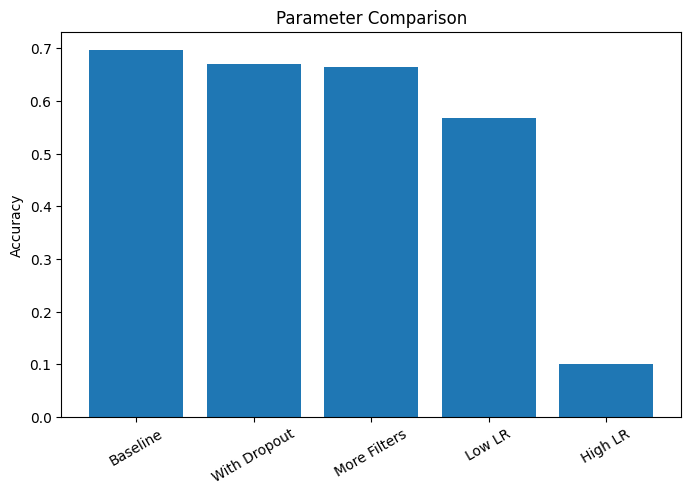

In [14]:
plt.figure(figsize=(8,5))
plt.bar(results.keys(), results.values())
plt.xticks(rotation=30)
plt.title("Parameter Comparison")
plt.ylabel("Accuracy")
plt.show()

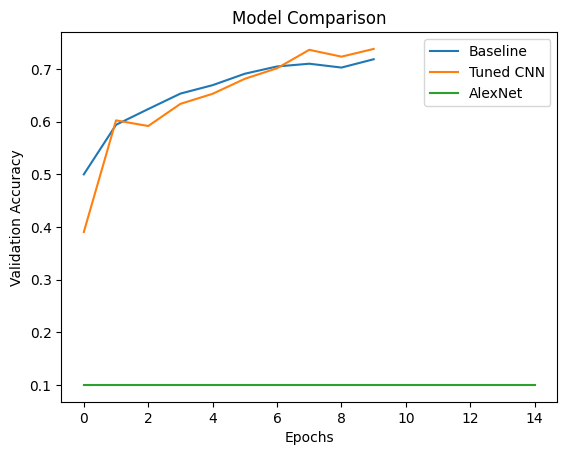

In [15]:
import matplotlib.pyplot as plt

plt.plot(history.history['val_accuracy'], label='Baseline')
plt.plot(history2.history['val_accuracy'], label='Tuned CNN')
plt.plot(history3.history['val_accuracy'], label='AlexNet')

plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Validation Accuracy")
plt.legend()
plt.show()

**week 7 ** Implement pre-trained models LeNet, AlexNet, ZF-Net, VGGNet, GoogLeNet, ResNet and note your observations. Also apply above models on your own dataset.


Lenet

In [17]:
def LeNet():
    model = models.Sequential()

    model.add(layers.Conv2D(6, (5,5), activation='tanh', input_shape=(32,32,3)))
    model.add(layers.AveragePooling2D(pool_size=(2,2)))

    model.add(layers.Conv2D(16, (5,5), activation='tanh'))
    model.add(layers.AveragePooling2D(pool_size=(2,2)))

    model.add(layers.Flatten())

    model.add(layers.Dense(120, activation='tanh'))
    model.add(layers.Dense(84, activation='tanh'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model_lenet = LeNet()
model_lenet.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_lenet = model_lenet.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 6ms/step - accuracy: 0.3653 - loss: 1.7834 - val_accuracy: 0.4238 - val_loss: 1.6154
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.4516 - loss: 1.5331 - val_accuracy: 0.4738 - val_loss: 1.4733
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5008 - loss: 1.3990 - val_accuracy: 0.4978 - val_loss: 1.4024
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.5338 - loss: 1.3087 - val_accuracy: 0.5196 - val_loss: 1.3471
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.5576 - loss: 1.2466 - val_accuracy: 0.5405 - val_loss: 1.2957


Alexnet

In [19]:
def AlexNet():
    model = models.Sequential()

    model.add(layers.Conv2D(96, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(384, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(256, (3,3), activation='relu', padding='same'))

    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dropout(0.5))

    model.add(layers.Dense(10, activation='softmax'))

    return model

model_alex = AlexNet()
model_alex.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_alex = model_alex.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 38s 21ms/step - accuracy: 0.3824 - loss: 1.6593 - val_accuracy: 0.5030 - val_loss: 1.3845
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 29s 19ms/step - accuracy: 0.5630 - loss: 1.2236 - val_accuracy: 0.6094 - val_loss: 1.0959
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 41s 19ms/step - accuracy: 0.6373 - loss: 1.0232 - val_accuracy: 0.6408 - val_loss: 1.0259
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.6805 - loss: 0.9046 - val_accuracy: 0.6832 - val_loss: 0.8864
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 28s 18ms/step - accuracy: 0.7168 - loss: 0.8037 - val_accuracy: 0.7053 - val_loss: 0.8620


ZF-Net

In [21]:
def ZFNet():
    model = models.Sequential()

    model.add(layers.Conv2D(32, (7,7), strides=2, activation='relu',
                            padding='same', input_shape=(32,32,3)))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(64, (5,5), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))

    model.add(layers.Flatten())
    model.add(layers.Dense(256, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model_zf = ZFNet()
model_zf.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_zf = model_zf.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 18s 8ms/step - accuracy: 0.4292 - loss: 1.5640 - val_accuracy: 0.5086 - val_loss: 1.3604
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 12s 5ms/step - accuracy: 0.5699 - loss: 1.2034 - val_accuracy: 0.5766 - val_loss: 1.1759
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6339 - loss: 1.0280 - val_accuracy: 0.6331 - val_loss: 1.0545
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 4ms/step - accuracy: 0.6839 - loss: 0.8937 - val_accuracy: 0.6503 - val_loss: 1.0065
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 6s 4ms/step - accuracy: 0.7229 - loss: 0.7777 - val_accuracy: 0.6656 - val_loss: 0.9950


VGGNet

In [22]:
def VGGNet():
    model = models.Sequential()

    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same', input_shape=(32,32,3)))
    model.add(layers.Conv2D(64, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.Conv2D(128, (3,3), activation='relu', padding='same'))
    model.add(layers.MaxPooling2D())

    model.add(layers.Flatten())

    model.add(layers.Dense(512, activation='relu'))
    model.add(layers.Dense(10, activation='softmax'))

    return model

model_vgg = VGGNet()
model_vgg.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_vgg = model_vgg.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 22s 11ms/step - accuracy: 0.5241 - loss: 1.3179 - val_accuracy: 0.6532 - val_loss: 0.9814
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7061 - loss: 0.8339 - val_accuracy: 0.7205 - val_loss: 0.7983
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.7859 - loss: 0.6136 - val_accuracy: 0.7593 - val_loss: 0.7143
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 9ms/step - accuracy: 0.8421 - loss: 0.4528 - val_accuracy: 0.7575 - val_loss: 0.7443
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 13s 8ms/step - accuracy: 0.8959 - loss: 0.2959 - val_accuracy: 0.7540 - val_loss: 0.8748




---GoogLeNet



In [23]:
def GoogLeNet():
    inputs = tf.keras.Input(shape=(32,32,3))

    x = layers.Conv2D(64, (3,3), activation='relu')(inputs)

    # Simple Inception-like block
    tower1 = layers.Conv2D(32, (1,1), activation='relu')(x)
    tower2 = layers.Conv2D(32, (3,3), padding='same', activation='relu')(x)

    x = layers.concatenate([tower1, tower2])

    x = layers.MaxPooling2D()(x)
    x = layers.Flatten()(x)

    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model_google = GoogLeNet()
model_google.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_google = model_google.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 15s 7ms/step - accuracy: 0.5303 - loss: 1.3310 - val_accuracy: 0.6185 - val_loss: 1.1026
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6621 - loss: 0.9761 - val_accuracy: 0.6516 - val_loss: 1.0069
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7056 - loss: 0.8540 - val_accuracy: 0.6680 - val_loss: 0.9693
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7392 - loss: 0.7617 - val_accuracy: 0.6669 - val_loss: 0.9735
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7651 - loss: 0.6805 - val_accuracy: 0.6785 - val_loss: 0.9594


ResNet

In [24]:
def res_block(x, filters):
    shortcut = x
    x = layers.Conv2D(filters, (3,3), padding='same', activation='relu')(x)
    x = layers.Conv2D(filters, (3,3), padding='same')(x)
    x = layers.add([x, shortcut])
    return layers.Activation('relu')(x)

def ResNet():
    inputs = tf.keras.Input(shape=(32,32,3))

    x = layers.Conv2D(32, (3,3), padding='same', activation='relu')(inputs)
    x = res_block(x, 32)
    x = layers.MaxPooling2D()(x)

    x = layers.Flatten()(x)
    outputs = layers.Dense(10, activation='softmax')(x)

    model = models.Model(inputs, outputs)
    return model

model_res = ResNet()
model_res.compile(optimizer='adam', loss='sparse_categorical_crossentropy', metrics=['accuracy'])

history_res = model_res.fit(X_train, y_train, epochs=5, validation_data=(X_test, y_test))

Epoch 1/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 14s 7ms/step - accuracy: 0.5219 - loss: 1.3523 - val_accuracy: 0.6228 - val_loss: 1.0886
Epoch 2/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.6698 - loss: 0.9563 - val_accuracy: 0.6691 - val_loss: 0.9509
Epoch 3/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7145 - loss: 0.8267 - val_accuracy: 0.6834 - val_loss: 0.9199
Epoch 4/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 7s 5ms/step - accuracy: 0.7484 - loss: 0.7273 - val_accuracy: 0.6798 - val_loss: 0.9325
Epoch 5/5
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 8s 5ms/step - accuracy: 0.7740 - loss: 0.6497 - val_accuracy: 0.6840 - val_loss: 0.9433


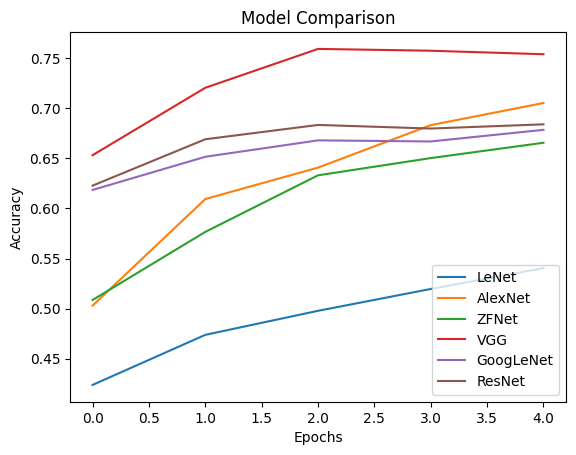

In [25]:
import matplotlib.pyplot as plt

plt.plot(history_lenet.history['val_accuracy'], label='LeNet')
plt.plot(history_alex.history['val_accuracy'], label='AlexNet')
plt.plot(history_zf.history['val_accuracy'], label='ZFNet')
plt.plot(history_vgg.history['val_accuracy'], label='VGG')
plt.plot(history_google.history['val_accuracy'], label='GoogLeNet')
plt.plot(history_res.history['val_accuracy'], label='ResNet')

plt.legend()
plt.title("Model Comparison")
plt.xlabel("Epochs")
plt.ylabel("Accuracy")
plt.show()

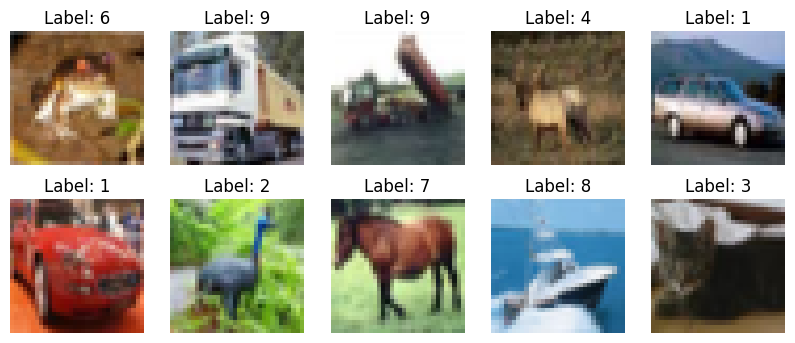

In [26]:
import matplotlib.pyplot as plt

plt.figure(figsize=(10,4))

for i in range(10):
    plt.subplot(2,5,i+1)
    plt.imshow(X_train[i])   # ✅ correct for CIFAR
    plt.title(f"Label: {y_train[i][0]}")
    plt.axis('off')

plt.show()

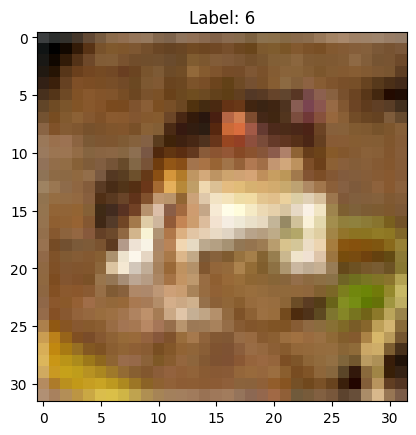

In [27]:
plt.imshow(X_train[0])
plt.title(f"Label: {y_train[0][0]}")
plt.show()

**week 8 **

Write a program to Visualizing Convolutional Neural Networks(display result of convolution and pooling operations as feature map)


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 395ms/step


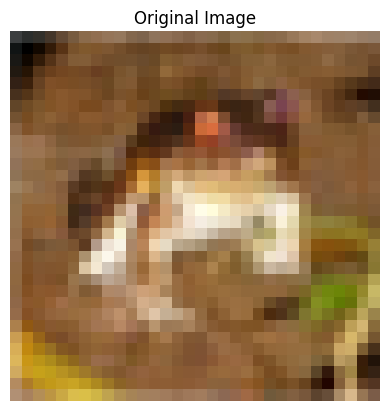

Layer 1 Shape: (1, 32, 32, 3)


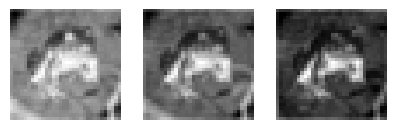

Layer 2 Shape: (1, 30, 30, 32)


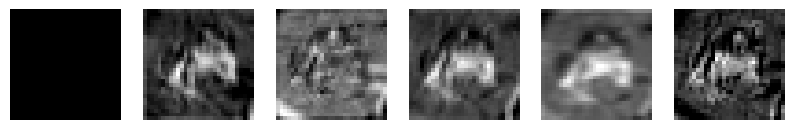

Layer 3 Shape: (1, 15, 15, 32)


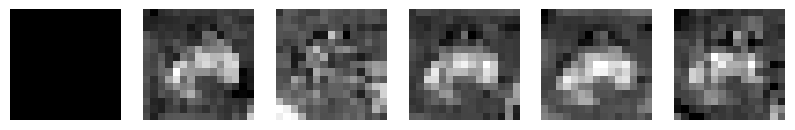

Layer 4 Shape: (1, 13, 13, 64)


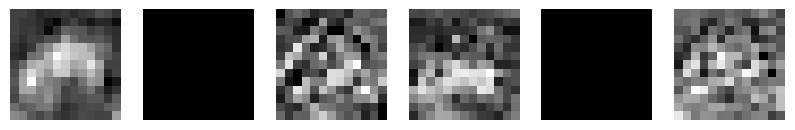

Layer 5 Shape: (1, 6, 6, 64)


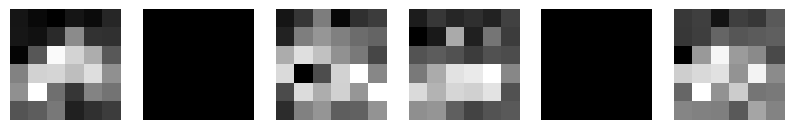

In [39]:
# Import libraries
import tensorflow as tf
from tensorflow.keras import layers, models
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10

# Load dataset
(X_train, y_train), (X_test, y_test) = cifar10.load_data()
X_train = X_train / 255.0

# -------------------------------
# Build model using Functional API (FIX)
# -------------------------------
inputs = tf.keras.Input(shape=(32,32,3))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

model = models.Model(inputs=inputs, outputs=x)

# -------------------------------
# Create feature map model
# -------------------------------
layer_outputs = [layer.output for layer in model.layers]
feature_map_model = models.Model(inputs=model.input, outputs=layer_outputs)

# -------------------------------
# Select one image
# -------------------------------
img = X_train[0].reshape(1,32,32,3)

# -------------------------------
# Get feature maps
# -------------------------------
feature_maps = feature_map_model.predict(img)

# -------------------------------
# Show original image
# -------------------------------
plt.imshow(X_train[0])
plt.title("Original Image")
plt.axis('off')
plt.show()

# -------------------------------
# Display feature maps
# -------------------------------
for i, fmap in enumerate(feature_maps):
    print("Layer", i+1, "Shape:", fmap.shape)

    plt.figure(figsize=(10,3))

    for j in range(min(6, fmap.shape[-1])):  # safe indexing
        plt.subplot(1,6,j+1)
        plt.imshow(fmap[0, :, :, j], cmap='gray')
        plt.axis('off')

    plt.show()

implement Guided Backpropagation to discover which input pixels influence the perceptron.(Give all the intermediate steps and write your observations)

In [40]:
import tensorflow as tf
import numpy as np
import matplotlib.pyplot as plt
from tensorflow.keras.datasets import cifar10
from tensorflow.keras import layers, models

In [41]:
(X_train, y_train), (X_test, y_test) = cifar10.load_data()

X_train = X_train / 255.0

In [42]:
inputs = tf.keras.Input(shape=(32,32,3))

x = layers.Conv2D(32, (3,3), activation='relu')(inputs)
x = layers.MaxPooling2D()(x)

x = layers.Conv2D(64, (3,3), activation='relu')(x)
x = layers.MaxPooling2D()(x)

x = layers.Flatten()(x)
outputs = layers.Dense(10, activation='softmax')(x)

model = models.Model(inputs, outputs)
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# Train quickly
model.fit(X_train, y_train, epochs=2, batch_size=32)

Epoch 1/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 9s 5ms/step - accuracy: 0.4812 - loss: 1.4713
Epoch 2/2
1563/1563 ━━━━━━━━━━━━━━━━━━━━ 5s 3ms/step - accuracy: 0.6037 - loss: 1.1406


In [43]:
@tf.function
def guided_backprop(model, image, class_index):
    with tf.GradientTape() as tape:
        tape.watch(image)
        preds = model(image)
        loss = preds[:, class_index]

    grads = tape.gradient(loss, image)

    # Guided Backprop rule: keep only positive gradients
    guided_grads = tf.maximum(grads, 0)

    return guided_grads

In [44]:
img = X_train[0]
img = np.expand_dims(img, axis=0)

pred = model.predict(img)
class_idx = np.argmax(pred)

1/1 ━━━━━━━━━━━━━━━━━━━━ 1s 596ms/step


In [45]:
grads = guided_backprop(model, img, class_idx)
grads = grads[0].numpy()

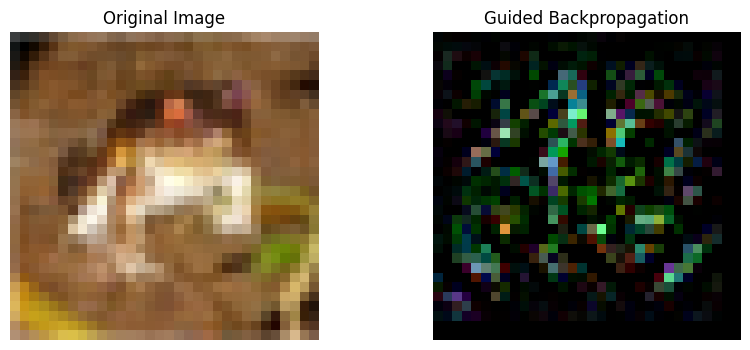

In [46]:
# Normalize gradients for display
grads = (grads - grads.min()) / (grads.max() - grads.min())

plt.figure(figsize=(10,4))

# Original Image
plt.subplot(1,2,1)
plt.imshow(img[0])
plt.title("Original Image")
plt.axis('off')

# Guided Backprop Image
plt.subplot(1,2,2)
plt.imshow(grads)
plt.title("Guided Backpropagation")
plt.axis('off')

plt.show()

“Guided Backpropagation highlights the important pixels contributing to the classification decision. It suppresses negative gradients and retains only positive influences, resulting in clearer and more interpretable visualizations compared to standard backpropagation. The highlighted regions correspond to edges, textures, and object-specific features.”Bright areas → important pixels
Dark areas → less important